In [2]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob
import cmasher as cmr

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

In [3]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

n_lat       = len(ERA5.lat)
n_lon       = len(ERA5.lon)
n_flat      = n_lat*n_lon
n_time      = len(ERA5.time)
weights_1D  = np.array(ERA5['weights'].data).reshape(n_flat)

amip_hist_models        = np.load('./data/helper/amip_hist_models.npy')
amip_piForcing_models   = np.load('./data/helper/amip_piForcing_models.npy')
historical_models       = np.load('./data/helper/historical_models.npy')

amip_hist_n_ensembles       = np.load('./data/helper/amip_hist_n_ensembles.npy')
amip_piForcing_n_ensembles  = np.load('./data/helper/amip_piForcing_n_ensembles.npy')
historical_n_ensembles      = np.load('./data/helper/historical_n_ensembles.npy')

print("amip_hist_models =", amip_hist_models)
print("amip_piForcing_models =", amip_piForcing_models)
print("historical_models =", historical_models)

print("amip_hist_n_ensembles =", amip_hist_n_ensembles)
print("amip_piForcing_n_ensembles =", amip_piForcing_n_ensembles)
print("historical_n_ensembles =", historical_n_ensembles)

n_amip_hist         = len(amip_hist_models)
n_amip_piForcing    = len(amip_piForcing_models)
n_historical        = len(historical_models)

print(n_time,n_lat,n_lon,n_flat)

amip_hist_models = ['BCC-CSM2-MR' 'CAMS-CSM1-0' 'CESM2' 'CIESM' 'CNRM-CM6-1' 'CNRM-CM6-1-HR'
 'CNRM-ESM2-1' 'CanESM5' 'FGOALS-f3-L' 'FGOALS-g3' 'FIO-ESM-2-0'
 'IITM-ESM' 'IPSL-CM6A-LR' 'MIROC6' 'MRI-ESM2-0' 'TaiESM1']
amip_piForcing_models = ['CESM2' 'CNRM-CM6-1' 'CanESM5' 'HadGEM3-GC31-LL' 'IPSL-CM6A-LR' 'MIROC6'
 'MRI-ESM2-0' 'TaiESM1']
historical_models = ['ACCESS-CM2' 'ACCESS-ESM1-5' 'AWI-CM-1-1-MR' 'AWI-ESM-1-1-LR'
 'BCC-CSM2-MR' 'BCC-ESM1' 'CAMS-CSM1-0' 'CAS-ESM2-0' 'CESM2' 'CESM2-FV2'
 'CESM2-WACCM' 'CESM2-WACCM-FV2' 'CIESM' 'CMCC-CM2-HR4' 'CMCC-CM2-SR5'
 'CMCC-ESM2' 'CNRM-CM6-1' 'CNRM-CM6-1-HR' 'CNRM-ESM2-1' 'CanESM5'
 'CanESM5-CanOE' 'E3SM-1-0' 'E3SM-1-1' 'E3SM-1-1-ECA' 'EC-Earth3'
 'EC-Earth3-AerChem' 'EC-Earth3-Veg' 'EC-Earth3-Veg-LR' 'FGOALS-f3-L'
 'FGOALS-g3' 'FIO-ESM-2-0' 'GISS-E2-1-G' 'GISS-E2-1-G-CC' 'GISS-E2-1-H'
 'IITM-ESM' 'INM-CM4-8' 'INM-CM5-0' 'IPSL-CM5A2-INCA' 'IPSL-CM6A-LR'
 'IPSL-CM6A-LR-INCA' 'KACE-1-0-G' 'KIOST-ESM' 'MIROC6' 'MPI-ESM-1-2-HAM'
 'MPI-ESM1-2-HR'

In [4]:
# 16-panel plotting script

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path


def plot_16_model_maps(
    maps,
    model_names,
    lat,
    lon,
    *,
    title="",
    colorbar_label="",
    cmap="RdBu_r",
    vlim=None,
    robust_percentile=98,
    number_of_levels=21,
    central_longitude=210,
    savepath=None,
    dpi=200,
):
    """
    Plot up to 16 model maps on a shared 4x4 global-map figure.

    Parameters
    ----------
    maps
        Array with shape (model, lat, lon).
    model_names
        Model names in the same order as maps.
    lat, lon
        One-dimensional spatial coordinates.
    vlim
        Absolute color limit. If None, it is calculated robustly from all
        panels using robust_percentile.
    savepath
        Optional output path, such as "./figures/covRTi_amip_hist.png".

    Returns
    -------
    fig, axes
        Matplotlib figure and flattened axes array.
    """
    maps = np.asarray(maps)
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    model_names = list(model_names)

    if maps.ndim != 3:
        raise ValueError(
            f"maps has shape {maps.shape}; "
            "expected (model, lat, lon)"
        )

    if maps.shape[0] != len(model_names):
        raise ValueError(
            f"There are {maps.shape[0]} maps but "
            f"{len(model_names)} model names"
        )

    if len(model_names) > 16:
        raise ValueError(
            "This function supports at most 16 models"
        )

    if maps.shape[1:] != (len(lat), len(lon)):
        raise ValueError(
            f"Map shape {maps.shape[1:]} does not match "
            f"lat/lon lengths {(len(lat), len(lon))}"
        )

    # Use one symmetric color scale across all models.
    if vlim is None:
        finite_values = np.abs(maps[np.isfinite(maps)])

        if finite_values.size == 0:
            raise ValueError("The maps contain no finite values")

        vlim = np.percentile(
            finite_values,
            robust_percentile,
        )

        if vlim == 0:
            vlim = np.max(finite_values)

        if vlim == 0:
            vlim = 1.0

    levels = np.linspace(
        -vlim,
        vlim,
        number_of_levels,
    )

    projection = ccrs.Robinson(
        central_longitude=central_longitude
    )

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(17, 10.5),
        subplot_kw={"projection": projection},
    )

    axes = np.asarray(axes).ravel()
    mappable = None

    for model_index, ax in enumerate(axes):
        if model_index >= len(model_names):
            ax.set_visible(False)
            continue

        model_map = maps[model_index]

        # Close the longitude seam unless the coordinate already includes it.
        if np.isclose(
            abs(lon[-1] - lon[0]),
            360.0,
        ):
            plot_map = model_map
            plot_lon = lon
        else:
            plot_map, plot_lon = add_cyclic_point(
                model_map,
                coord=lon,
                axis=-1,
            )

        mappable = ax.contourf(
            plot_lon,
            lat,
            plot_map,
            levels=levels,
            cmap=cmap,
            extend="both",
            transform=ccrs.PlateCarree(),
        )

        ax.set_global()
        ax.coastlines(
            resolution="110m",
            linewidth=0.5,
            color="0.2",
        )

        ax.gridlines(
            linewidth=0.3,
            color="0.35",
            alpha=0.4,
            linestyle=":",
        )

        ax.set_title(
            f"{model_index + 1}. {model_names[model_index]}",
            fontsize=10,
            pad=4,
        )

    fig.suptitle(
        title,
        fontsize=16,
        y=0.965,
    )

    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.92,
        bottom=0.105,
        wspace=0.025,
        hspace=0.10,
    )

    colorbar_axis = fig.add_axes(
        [0.22, 0.045, 0.56, 0.025]
    )

    colorbar = fig.colorbar(
        mappable,
        cax=colorbar_axis,
        orientation="horizontal",
        extend="both",
    )

    colorbar.set_label(
        colorbar_label,
        fontsize=11,
    )
    colorbar.ax.tick_params(
        labelsize=9,
    )

    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            savepath,
            dpi=dpi,
            bbox_inches="tight",
        )

        print(f"Saved: {savepath}")

    return fig, axes

In [5]:
## Cell 1: AMIP-hist, calculate the three maps for all models and ens members 
'''
import xarray as xr
from pathlib import Path

covRTi_amip_hist   = {}
covTRi_amip_hist   = {}
regTiRi_amip_hist  = {}



data_root = Path(
    "/scratch/leiff/MCA/amip_clean/data"
)

for m,model in enumerate(amip_hist_models):
    path_N = (
        data_root
        / "AMIP"
        / model
        / (
            f"N_Amon_{model}_amip-hist_combined_"
            "187001-201412_g025.nc"
        )
    )
    path_T = (
        data_root
        / "AMIP"
        / model
        / (
            f"tas_Amon_{model}_amip-hist_combined_"
            "187001-201412_g025.nc"
        )
    )

    member_covRTi   = []
    member_covTRi   = []
    member_regTiRi  = []

    ## Need to open and process with members in mind
    T_ds        = xc.open_dataset(path_T).sel(time=slice('2000-03','2014-12'))
    N_ds        = xc.open_dataset(path_N).sel(time=slice('2000-03','2014-12'))

    T_ds['T']   = np.sum(T_ds['tas']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])
    N_ds['Ng']  = np.sum(N_ds['N']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])

    # display(T_ds)
    # display(N_ds)


    for e in np.arange(amip_hist_n_ensembles[m]):
        print(model)
        print(e)


        # Move spatial and global N and tas into detrended anomalies
        tas_here = detrend_monthly_fast(np.array(T_ds['tas'].data)[e])
        N_here   = detrend_monthly_fast(np.array(N_ds['N'].data)[e])

        tas_here_reshaped    = tas_here.reshape(n_time,n_flat)
        N_here_reshaped      = N_here.reshape(n_time,n_flat)

        T_here   = detrend_monthly_fast(np.array(T_ds['T'].data)[e])
        Ng_here  = detrend_monthly_fast(np.array(N_ds['Ng'].data)[e])

        # print(tas_here_reshaped.shape)
        # print(Ng_here.shape)
        # kill
        
        covRTi_here             = MCA_dave(tas_here_reshaped, Ng_here, weights_1D, standardized=True).reshape(n_lat,n_lon)
        covTRi_here             = MCA_dave(N_here_reshaped, T_here, weights_1D, standardized=True).reshape(n_lat,n_lon)
        _,_,regTiRi_here,_      = lag_linregress_3D(tas_here,N_here)
        
        member_covRTi.append(covRTi_here)
        member_covTRi.append(covTRi_here)
        member_regTiRi.append(regTiRi_here)

    # Shape: (number_of_members, lat, lon)
    covRTi_amip_hist[model] = np.stack(
        member_covRTi,
        axis=0,
    )

    covTRi_amip_hist[model] = np.stack(
        member_covTRi,
        axis=0,
    )

    regTiRi_amip_hist[model] = np.stack(
        member_regTiRi,
        axis=0,
    )
  ''' 

'\nimport xarray as xr\nfrom pathlib import Path\n\ncovRTi_amip_hist   = {}\ncovTRi_amip_hist   = {}\nregTiRi_amip_hist  = {}\n\n\n\ndata_root = Path(\n    "/scratch/leiff/MCA/amip_clean/data"\n)\n\nfor m,model in enumerate(amip_hist_models):\n    path_N = (\n        data_root\n        / "AMIP"\n        / model\n        / (\n            f"N_Amon_{model}_amip-hist_combined_"\n            "187001-201412_g025.nc"\n        )\n    )\n    path_T = (\n        data_root\n        / "AMIP"\n        / model\n        / (\n            f"tas_Amon_{model}_amip-hist_combined_"\n            "187001-201412_g025.nc"\n        )\n    )\n\n    member_covRTi   = []\n    member_covTRi   = []\n    member_regTiRi  = []\n\n    ## Need to open and process with members in mind\n    T_ds        = xc.open_dataset(path_T).sel(time=slice(\'2000-03\',\'2014-12\'))\n    N_ds        = xc.open_dataset(path_N).sel(time=slice(\'2000-03\',\'2014-12\'))\n\n    T_ds[\'T\']   = np.sum(T_ds[\'tas\']*ERA5[\'weights\'],axis=(2,3))

In [6]:
## Stats and significance functions

import numpy as np
from scipy import stats

alpha = 0.05

def count_sign_agreement(maps, reference):
    """
    Number of maps having the same nonzero sign as reference.

    maps:      (n_samples, n_lat, n_lon)
    reference: (n_lat, n_lon)
    """
    maps = np.asarray(maps)

    agrees = (
        ((maps > 0) & (reference > 0)) |
        ((maps < 0) & (reference < 0))
    )

    # NaNs are not counted as agreement
    agrees &= np.isfinite(maps) & np.isfinite(reference)

    return np.sum(agrees, axis=0)


def one_sample_test(maps, alpha=0.05):
    """
    Gridpoint one-sample t-test of mean(maps) against zero.

    Returns
    -------
    pvalue  : p-value at each grid point
    sig     : True where p < alpha
    n_valid : number of valid samples at each grid point

    At least two samples are needed. Results are NaN/False otherwise.
    """
    maps = np.asarray(maps)
    n_valid = np.sum(np.isfinite(maps), axis=0)

    with np.errstate(invalid="ignore", divide="ignore"):
        result = stats.ttest_1samp(
            maps,
            popmean=0.0,
            axis=0,
            nan_policy="omit"
        )

    pvalue = np.asarray(result.pvalue)
    pvalue = np.where(n_valid >= 2, pvalue, np.nan)
    sig = (pvalue < alpha) & (n_valid >= 2)

    return pvalue, sig, n_valid

def fdr_bh(pvalue, q=0.05):
    """
    Benjamini-Hochberg FDR correction across all finite grid-point p-values.

    Parameters
    ----------
    pvalue : array
        Map of uncorrected p-values.
    q : float
        Desired false-discovery rate.

    Returns
    -------
    pvalue_fdr : array
        Benjamini-Hochberg adjusted p-values.
    sig_fdr : bool array
        True where the result passes the FDR threshold.
    """
    pvalue = np.asarray(pvalue, dtype=float)

    flat_p = pvalue.ravel()
    valid = np.isfinite(flat_p)

    pvalue_fdr_flat = np.full(flat_p.shape, np.nan)
    sig_fdr_flat = np.zeros(flat_p.shape, dtype=bool)

    valid_p = flat_p[valid]
    m = valid_p.size

    if m == 0:
        return (
            pvalue_fdr_flat.reshape(pvalue.shape),
            sig_fdr_flat.reshape(pvalue.shape)
        )

    # Sort finite p-values
    order = np.argsort(valid_p)
    sorted_p = valid_p[order]
    ranks = np.arange(1, m + 1)

    # Determine which hypotheses pass the BH threshold
    bh_threshold = q * ranks / m
    below = sorted_p <= bh_threshold

    reject_sorted = np.zeros(m, dtype=bool)

    if np.any(below):
        largest_passing_rank = np.max(np.where(below)[0])
        reject_sorted[:largest_passing_rank + 1] = True

    # BH-adjusted p-values
    adjusted_sorted = sorted_p * m / ranks

    # Enforce monotonicity
    adjusted_sorted = np.minimum.accumulate(
        adjusted_sorted[::-1]
    )[::-1]

    adjusted_sorted = np.clip(adjusted_sorted, 0.0, 1.0)

    # Return values to their original order
    adjusted_valid = np.empty(m)
    adjusted_valid[order] = adjusted_sorted

    rejected_valid = np.empty(m, dtype=bool)
    rejected_valid[order] = reject_sorted

    pvalue_fdr_flat[valid] = adjusted_valid
    sig_fdr_flat[valid] = rejected_valid

    return (
        pvalue_fdr_flat.reshape(pvalue.shape),
        sig_fdr_flat.reshape(pvalue.shape)
    )

In [7]:
#  Cell 2: AMIP-hist, Save/Load AMIP-hist

# np.save("./data/maps_2000_2014/covRTi_amip_hist.npy",covRTi_amip_hist)
# np.save("./data/maps_2000_2014/covTRi_amip_hist.npy",covTRi_amip_hist)
# np.save("./data/maps_2000_2014/regTiRi_amip_hist.npy",regTiRi_amip_hist)


covRTi_amip_hist    = np.load("./data/maps_2000_2014/covRTi_amip_hist.npy",allow_pickle=True).item()
covTRi_amip_hist    = np.load("./data/maps_2000_2014/covTRi_amip_hist.npy",allow_pickle=True).item()
regTiRi_amip_hist   = np.load("./data/maps_2000_2014/regTiRi_amip_hist.npy",allow_pickle=True).item()

In [8]:
# Cell 3: AMIP-hist, Calculate ens means for each model and multimodel means for each of the 3 maps
shape_models = (n_amip_hist, n_lat, n_lon)

# Ensemble means
covRTi_amip_hist_ensmeans  = np.full(shape_models, np.nan)
covTRi_amip_hist_ensmeans  = np.full(shape_models, np.nan)
regTiRi_amip_hist_ensmeans = np.full(shape_models, np.nan)

# Number of ensemble members agreeing with each ensemble mean
covRTi_amip_hist_ens_nagree  = np.zeros(shape_models, dtype=int)
covTRi_amip_hist_ens_nagree  = np.zeros(shape_models, dtype=int)
regTiRi_amip_hist_ens_nagree = np.zeros(shape_models, dtype=int)

# Number of valid ensemble members
covRTi_amip_hist_ens_nvalid  = np.zeros(shape_models, dtype=int)
covTRi_amip_hist_ens_nvalid  = np.zeros(shape_models, dtype=int)
regTiRi_amip_hist_ens_nvalid = np.zeros(shape_models, dtype=int)

# Ensemble-level p-values and significance masks
covRTi_amip_hist_ens_pvalue  = np.full(shape_models, np.nan)
covTRi_amip_hist_ens_pvalue  = np.full(shape_models, np.nan)
regTiRi_amip_hist_ens_pvalue = np.full(shape_models, np.nan)

covRTi_amip_hist_ens_sig  = np.zeros(shape_models, dtype=bool)
covTRi_amip_hist_ens_sig  = np.zeros(shape_models, dtype=bool)
regTiRi_amip_hist_ens_sig = np.zeros(shape_models, dtype=bool)



for i in np.arange(n_amip_hist):  # i is models

    model = amip_hist_models[i]

    # Member maps have shape (n_members, n_lat, n_lon)
    covRT_members  = np.asarray(covRTi_amip_hist[model])
    covTR_members  = np.asarray(covTRi_amip_hist[model])
    regTiRi_members = np.asarray(regTiRi_amip_hist[model])

    # ORIGINAL: ensemble means
    covRTi_amip_hist_ensmeans[i]  = np.nanmean(covRT_members, axis=0)
    covTRi_amip_hist_ensmeans[i]  = np.nanmean(covTR_members, axis=0)
    regTiRi_amip_hist_ensmeans[i] = np.nanmean(regTiRi_members, axis=0)

    # ADDED: members agreeing with the ensemble-mean sign
    covRTi_amip_hist_ens_nagree[i] = count_sign_agreement(
        covRT_members, covRTi_amip_hist_ensmeans[i]
    )
    covTRi_amip_hist_ens_nagree[i] = count_sign_agreement(
        covTR_members, covTRi_amip_hist_ensmeans[i]
    )
    regTiRi_amip_hist_ens_nagree[i] = count_sign_agreement(
        regTiRi_members, regTiRi_amip_hist_ensmeans[i]
    )

    # ADDED: significance of each ensemble mean versus zero
    (
        covRTi_amip_hist_ens_pvalue[i],
        covRTi_amip_hist_ens_sig[i],
        covRTi_amip_hist_ens_nvalid[i],
    ) = one_sample_test(covRT_members, alpha)

    (
        covTRi_amip_hist_ens_pvalue[i],
        covTRi_amip_hist_ens_sig[i],
        covTRi_amip_hist_ens_nvalid[i],
    ) = one_sample_test(covTR_members, alpha)

    (
        regTiRi_amip_hist_ens_pvalue[i],
        regTiRi_amip_hist_ens_sig[i],
        regTiRi_amip_hist_ens_nvalid[i],
    ) = one_sample_test(regTiRi_members, alpha)

## Agreement fractions for each model acros ensembles
covRTi_amip_hist_ens_fracagree = np.divide(
    covRTi_amip_hist_ens_nagree,
    covRTi_amip_hist_ens_nvalid,
    out=np.full(shape_models, np.nan),
    where=covRTi_amip_hist_ens_nvalid > 0
)

covTRi_amip_hist_ens_fracagree = np.divide(
    covTRi_amip_hist_ens_nagree,
    covTRi_amip_hist_ens_nvalid,
    out=np.full(shape_models, np.nan),
    where=covTRi_amip_hist_ens_nvalid > 0
)

regTiRi_amip_hist_ens_fracagree = np.divide(
    regTiRi_amip_hist_ens_nagree,
    regTiRi_amip_hist_ens_nvalid,
    out=np.full(shape_models, np.nan),
    where=regTiRi_amip_hist_ens_nvalid > 0
)


# Storage for spatially FDR-adjusted ensemble results
covRTi_amip_hist_ens_fdr_pvalue  = np.full(shape_models, np.nan)
covTRi_amip_hist_ens_fdr_pvalue  = np.full(shape_models, np.nan)
regTiRi_amip_hist_ens_fdr_pvalue = np.full(shape_models, np.nan)

covRTi_amip_hist_ens_fdr_sig  = np.zeros(shape_models, dtype=bool)
covTRi_amip_hist_ens_fdr_sig  = np.zeros(shape_models, dtype=bool)
regTiRi_amip_hist_ens_fdr_sig = np.zeros(shape_models, dtype=bool)

alpha = 0.05       # pointwise test level
fdr_q = 0.05       # desired false-discovery rate

for i in np.arange(n_amip_hist):

    (
        covRTi_amip_hist_ens_fdr_pvalue[i],
        covRTi_amip_hist_ens_fdr_sig[i],
    ) = fdr_bh(
        covRTi_amip_hist_ens_pvalue[i],
        q=fdr_q
    )

    (
        covTRi_amip_hist_ens_fdr_pvalue[i],
        covTRi_amip_hist_ens_fdr_sig[i],
    ) = fdr_bh(
        covTRi_amip_hist_ens_pvalue[i],
        q=fdr_q
    )

    (
        regTiRi_amip_hist_ens_fdr_pvalue[i],
        regTiRi_amip_hist_ens_fdr_sig[i],
    ) = fdr_bh(
        regTiRi_amip_hist_ens_pvalue[i],
        q=fdr_q
    )


'''
On to the multimodel mean (MMM)
'''

# ORIGINAL: equal-weighted multimodel means
covRTi_amip_hist_MMM  = np.nanmean(covRTi_amip_hist_ensmeans, axis=0)
covTRi_amip_hist_MMM  = np.nanmean(covTRi_amip_hist_ensmeans, axis=0)
regTiRi_amip_hist_MMM = np.nanmean(regTiRi_amip_hist_ensmeans, axis=0)

# ADDED: number of model ensemble means agreeing with the MMM sign
covRTi_amip_hist_MMM_nmodels_agree = count_sign_agreement(
    covRTi_amip_hist_ensmeans,
    covRTi_amip_hist_MMM
)

covTRi_amip_hist_MMM_nmodels_agree = count_sign_agreement(
    covTRi_amip_hist_ensmeans,
    covTRi_amip_hist_MMM
)

regTiRi_amip_hist_MMM_nmodels_agree = count_sign_agreement(
    regTiRi_amip_hist_ensmeans,
    regTiRi_amip_hist_MMM
)

# ADDED: significance of the MMM using model means as the samples
(
    covRTi_amip_hist_MMM_pvalue,
    covRTi_amip_hist_MMM_sig,
    covRTi_amip_hist_MMM_nmodels,
) = one_sample_test(covRTi_amip_hist_ensmeans, alpha)

(
    covTRi_amip_hist_MMM_pvalue,
    covTRi_amip_hist_MMM_sig,
    covTRi_amip_hist_MMM_nmodels,
) = one_sample_test(covTRi_amip_hist_ensmeans, alpha)

(
    regTiRi_amip_hist_MMM_pvalue,
    regTiRi_amip_hist_MMM_sig,
    regTiRi_amip_hist_MMM_nmodels,
) = one_sample_test(regTiRi_amip_hist_ensmeans, alpha)


# Spatial FDR correction of MMM p-value maps
(
    covRTi_amip_hist_MMM_fdr_pvalue,
    covRTi_amip_hist_MMM_fdr_sig,
) = fdr_bh(
    covRTi_amip_hist_MMM_pvalue,
    q=fdr_q
)

(
    covTRi_amip_hist_MMM_fdr_pvalue,
    covTRi_amip_hist_MMM_fdr_sig,
) = fdr_bh(
    covTRi_amip_hist_MMM_pvalue,
    q=fdr_q
)

(
    regTiRi_amip_hist_MMM_fdr_pvalue,
    regTiRi_amip_hist_MMM_fdr_sig,
) = fdr_bh(
    regTiRi_amip_hist_MMM_pvalue,
    q=fdr_q
)

## Test robustness by requiring 12 of 16 agree and are significant using FDR adjustment
covRTi_amip_hist_MMM_robust = (
    (covRTi_amip_hist_MMM_nmodels_agree >= 12) &
    covRTi_amip_hist_MMM_fdr_sig
)

covTRi_amip_hist_MMM_robust = (
    (covTRi_amip_hist_MMM_nmodels_agree >= 12) &
    covTRi_amip_hist_MMM_fdr_sig
)

regTiRi_amip_hist_MMM_robust = (
    (regTiRi_amip_hist_MMM_nmodels_agree >= 12) &
    regTiRi_amip_hist_MMM_fdr_sig
)

In [9]:
# 16-panel plotting script with optional robustness overlay

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path


def plot_16_model_maps(
    maps,
    model_names,
    lat,
    lon,
    *,
    title="",
    colorbar_label="",
    cmap="RdBu_r",
    vlim=None,
    robust_percentile=98,
    number_of_levels=21,
    central_longitude=210,

    # Optional significance/robustness overlay
    robust_masks=None,
    overlay_style="stipple",          # "stipple" or "hatch"
    overlay_for="significant",        # "significant" or "not_significant"

    # Custom scatter stippling controls
    stipple_stride=3,
    stipple_size=2.0,
    stipple_color="black",
    stipple_alpha=0.65,
    stipple_marker=".",

    # Hatching controls
    hatch_pattern="....",
    hatch_color="black",
    hatch_linewidth=0.5,

    savepath=None,
    dpi=200,
):
    """
    Plot up to 16 model maps on a shared 4x4 global-map figure.

    Parameters
    ----------
    maps : array-like
        Array with shape (model, lat, lon).

    model_names : sequence
        Model names in the same order as maps.

    lat, lon : array-like
        One-dimensional spatial coordinates.

    vlim : float or None
        Absolute color limit. If None, it is calculated from all panels
        using robust_percentile.

    robust_masks : array-like or None
        Boolean robustness/significance mask.

        Accepted shapes:
            (lat, lon)
                One common mask, such as an MMM robustness mask,
                applied to every panel.

            (model, lat, lon)
                A separate mask for each model panel.

        True means significant or robust. NaN values are not overlaid.

    overlay_style : {"stipple", "hatch"}
        Overlay method.

        "stipple" uses ax.scatter rather than Matplotlib's built-in
        stippling.

        "hatch" uses a contour hatch.

    overlay_for : {"significant", "not_significant"}
        Determines which portion of robust_masks receives the overlay.

        "significant":
            Overlay where robust_masks is True.

        "not_significant":
            Overlay where robust_masks is False.

    stipple_stride : int
        Plot one stipple point every stipple_stride grid cells in both
        latitude and longitude. Use 1 for every grid cell.

    stipple_size, stipple_color, stipple_alpha, stipple_marker
        Appearance controls for the scatter stippling.

    hatch_pattern : str
        Matplotlib hatch pattern. Examples include:
            "....", "////", "\\\\\\\\", "xxxx"

    hatch_color, hatch_linewidth
        Appearance controls for hatching.

    savepath : str, Path, or None
        Optional output path.

    dpi : int
        Output resolution when saving.

    Returns
    -------
    fig, axes
        Matplotlib figure and flattened axes array.
    """

    maps = np.asarray(maps)
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    model_names = list(model_names)

    # ---------------------------------------------------------
    # Validate maps and coordinates
    # ---------------------------------------------------------

    if maps.ndim != 3:
        raise ValueError(
            f"maps has shape {maps.shape}; "
            "expected (model, lat, lon)"
        )

    if maps.shape[0] != len(model_names):
        raise ValueError(
            f"There are {maps.shape[0]} maps but "
            f"{len(model_names)} model names"
        )

    if len(model_names) == 0:
        raise ValueError("At least one model is required")

    if len(model_names) > 16:
        raise ValueError(
            "This function supports at most 16 models"
        )

    if lat.ndim != 1 or lon.ndim != 1:
        raise ValueError(
            "lat and lon must be one-dimensional"
        )

    if maps.shape[1:] != (len(lat), len(lon)):
        raise ValueError(
            f"Map shape {maps.shape[1:]} does not match "
            f"lat/lon lengths {(len(lat), len(lon))}"
        )

    # ---------------------------------------------------------
    # Validate and prepare robustness masks
    # ---------------------------------------------------------

    if overlay_style not in {"stipple", "hatch"}:
        raise ValueError(
            "overlay_style must be 'stipple' or 'hatch'"
        )

    if overlay_for not in {
        "significant",
        "not_significant",
    }:
        raise ValueError(
            "overlay_for must be 'significant' "
            "or 'not_significant'"
        )

    if not isinstance(stipple_stride, (int, np.integer)):
        raise TypeError("stipple_stride must be an integer")

    if stipple_stride < 1:
        raise ValueError(
            "stipple_stride must be at least 1"
        )

    common_robust_mask = False

    if robust_masks is not None:
        robust_masks = np.asarray(robust_masks)

        if robust_masks.ndim == 2:
            if robust_masks.shape != (len(lat), len(lon)):
                raise ValueError(
                    f"2-D robust_masks has shape "
                    f"{robust_masks.shape}; expected "
                    f"{(len(lat), len(lon))}"
                )

            common_robust_mask = True

        elif robust_masks.ndim == 3:
            if robust_masks.shape != maps.shape:
                raise ValueError(
                    f"3-D robust_masks has shape "
                    f"{robust_masks.shape}; expected "
                    f"{maps.shape}"
                )

        else:
            raise ValueError(
                "robust_masks must have shape "
                "(lat, lon) or (model, lat, lon)"
            )

    # ---------------------------------------------------------
    # Shared symmetric color scale
    # ---------------------------------------------------------

    if vlim is None:
        finite_values = np.abs(
            maps[np.isfinite(maps)]
        )

        if finite_values.size == 0:
            raise ValueError(
                "The maps contain no finite values"
            )

        vlim = np.percentile(
            finite_values,
            robust_percentile,
        )

        if vlim == 0:
            vlim = np.max(finite_values)

        if vlim == 0:
            vlim = 1.0

    levels = np.linspace(
        -vlim,
        vlim,
        number_of_levels,
    )

    # Is the longitude seam already closed?
    longitude_is_cyclic = np.isclose(
        abs(lon[-1] - lon[0]),
        360.0,
    )

    # ---------------------------------------------------------
    # Create figure
    # ---------------------------------------------------------

    projection = ccrs.Robinson(
        central_longitude=central_longitude
    )

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(17, 10.5),
        subplot_kw={"projection": projection},
    )

    axes = np.asarray(axes).ravel()
    mappable = None

    # ---------------------------------------------------------
    # Plot panels
    # ---------------------------------------------------------

    for model_index, ax in enumerate(axes):

        if model_index >= len(model_names):
            ax.set_visible(False)
            continue

        model_map = maps[model_index]

        # Close the longitude seam for the filled contours.
        if longitude_is_cyclic:
            plot_map = model_map
            plot_lon = lon
        else:
            plot_map, plot_lon = add_cyclic_point(
                model_map,
                coord=lon,
                axis=-1,
            )

        mappable = ax.contourf(
            plot_lon,
            lat,
            plot_map,
            levels=levels,
            cmap=cmap,
            extend="both",
            transform=ccrs.PlateCarree(),
        )

        # -----------------------------------------------------
        # Optional significance/robustness overlay
        # -----------------------------------------------------

        if robust_masks is not None:

            if common_robust_mask:
                panel_mask = robust_masks
            else:
                panel_mask = robust_masks[model_index]

            # This permits Boolean masks and 0/1 masks while
            # ensuring NaNs are excluded.
            mask_is_valid = np.isfinite(panel_mask)
            mask_is_true = mask_is_valid & (
                panel_mask != 0
            )

            if overlay_for == "significant":
                display_mask = mask_is_true
            else:
                display_mask = (
                    mask_is_valid & ~mask_is_true
                )

            # Do not overlay missing portions of the plotted map.
            display_mask &= np.isfinite(model_map)

            if np.any(display_mask):

                if overlay_style == "stipple":

                    # Subsample the grid deterministically.
                    sampled_mask = display_mask[
                        ::stipple_stride,
                        ::stipple_stride,
                    ]

                    sampled_lat = lat[
                        ::stipple_stride
                    ]

                    sampled_lon = lon[
                        ::stipple_stride
                    ]

                    lat_indices, lon_indices = np.where(
                        sampled_mask
                    )

                    ax.scatter(
                        sampled_lon[lon_indices],
                        sampled_lat[lat_indices],
                        s=stipple_size,
                        c=stipple_color,
                        alpha=stipple_alpha,
                        marker=stipple_marker,
                        linewidths=0,
                        transform=ccrs.PlateCarree(),
                        zorder=4,
                    )

                elif overlay_style == "hatch":

                    hatch_map = np.where(
                        display_mask,
                        1.0,
                        np.nan,
                    )

                    if longitude_is_cyclic:
                        plot_hatch_map = hatch_map
                        plot_hatch_lon = lon
                    else:
                        (
                            plot_hatch_map,
                            plot_hatch_lon,
                        ) = add_cyclic_point(
                            hatch_map,
                            coord=lon,
                            axis=-1,
                        )

                    with mpl.rc_context({
                        "hatch.color": hatch_color,
                        "hatch.linewidth": hatch_linewidth,
                    }):
                        hatch_artist = ax.contourf(
                            plot_hatch_lon,
                            lat,
                            plot_hatch_map,
                            levels=[0.5, 1.5],
                            colors="none",
                            hatches=[hatch_pattern],
                            transform=ccrs.PlateCarree(),
                            zorder=4,
                        )

                        # Helps preserve hatch color across
                        # different Matplotlib versions.
                        if hasattr(
                            hatch_artist,
                            "collections",
                        ):
                            for collection in (
                                hatch_artist.collections
                            ):
                                collection.set_edgecolor(
                                    hatch_color
                                )
                                collection.set_facecolor(
                                    "none"
                                )

        # -----------------------------------------------------
        # Geographic formatting
        # -----------------------------------------------------

        ax.set_global()

        ax.coastlines(
            resolution="110m",
            linewidth=0.5,
            color="0.2",
            zorder=5,
        )

        ax.gridlines(
            linewidth=0.3,
            color="0.35",
            alpha=0.4,
            linestyle=":",
        )

        ax.set_title(
            f"{model_index + 1}. "
            f"{model_names[model_index]}",
            fontsize=10,
            pad=4,
        )

    # ---------------------------------------------------------
    # Figure title and colorbar
    # ---------------------------------------------------------

    fig.suptitle(
        title,
        fontsize=16,
        y=0.965,
    )

    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.92,
        bottom=0.105,
        wspace=0.025,
        hspace=0.10,
    )

    colorbar_axis = fig.add_axes(
        [0.22, 0.045, 0.56, 0.025]
    )

    colorbar = fig.colorbar(
        mappable,
        cax=colorbar_axis,
        orientation="horizontal",
        extend="both",
    )

    colorbar.set_label(
        colorbar_label,
        fontsize=11,
    )

    colorbar.ax.tick_params(
        labelsize=9,
    )

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------

    if savepath is not None:
        savepath = Path(savepath)

        savepath.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            savepath,
            dpi=dpi,
            bbox_inches="tight",
        )

        print(f"Saved: {savepath}")

    return fig, axes

In [10]:
# Test robustness separately for each of the 16 models.
#
# A grid point is robust when:
#   1. At least 75% of that model's valid ensemble members agree
#      with the ensemble-mean sign. This is equivalent to 12 of 16.
#   2. That model's ensemble mean passes the spatial FDR correction.
#
# Output shape for each robust mask:
#   (n_amip_hist, n_lat, n_lon), normally (16, lat, lon)

minimum_agreement_fraction = 0.75  # 0.75


# Number of agreeing members required at each model/grid point.
# np.ceil means, for example:
#   1 member  -> require 1
#   2 members -> require 2
#   3 members -> require 3
#   4 members -> require 3
#   5 members -> require 4
#   6 members -> require 5
#   8 members -> require 6
#  10 members -> require 8

covRTi_amip_hist_ens_required_agree = np.ceil(
    minimum_agreement_fraction *
    covRTi_amip_hist_ens_nvalid
).astype(int)

covTRi_amip_hist_ens_required_agree = np.ceil(
    minimum_agreement_fraction *
    covTRi_amip_hist_ens_nvalid
).astype(int)

regTiRi_amip_hist_ens_required_agree = np.ceil(
    minimum_agreement_fraction *
    regTiRi_amip_hist_ens_nvalid
).astype(int)


# Per-model robustness masks: shape (16, lat, lon)

covRTi_amip_hist_ens_robust = (
    (covRTi_amip_hist_ens_nvalid >= 2) &
    (
        covRTi_amip_hist_ens_nagree >=
        covRTi_amip_hist_ens_required_agree
    ) &
    covRTi_amip_hist_ens_fdr_sig
)

covTRi_amip_hist_ens_robust = (
    (covTRi_amip_hist_ens_nvalid >= 2) &
    (
        covTRi_amip_hist_ens_nagree >=
        covTRi_amip_hist_ens_required_agree
    ) &
    covTRi_amip_hist_ens_fdr_sig
)

regTiRi_amip_hist_ens_robust = (
    (regTiRi_amip_hist_ens_nvalid >= 2) &
    (
        regTiRi_amip_hist_ens_nagree >=
        regTiRi_amip_hist_ens_required_agree
    ) &
    regTiRi_amip_hist_ens_fdr_sig
)

covRTi_amip_hist_ens_GT75agree = (
    (covRTi_amip_hist_ens_nvalid >= 2) &
    (
        covRTi_amip_hist_ens_nagree >=
        covRTi_amip_hist_ens_required_agree
    ) 
)

covTRi_amip_hist_ens_GT75agree = (
    (covTRi_amip_hist_ens_nvalid >= 2) &
    (
        covTRi_amip_hist_ens_nagree >=
        covTRi_amip_hist_ens_required_agree
    ) 
)

regTiRi_amip_hist_ens_GT75agree = (
    (regTiRi_amip_hist_ens_nvalid >= 2) &
    (
        regTiRi_amip_hist_ens_nagree >=
        regTiRi_amip_hist_ens_required_agree
    ) 
)


# Confirm the resulting dimensions
print(
    "covRTi robust shape:",
    covRTi_amip_hist_ens_robust.shape,
)

print(
    "covTRi robust shape:",
    covTRi_amip_hist_ens_robust.shape,
)

print(
    "regTiRi robust shape:",
    regTiRi_amip_hist_ens_robust.shape,
)

covRTi robust shape: (16, 72, 144)
covTRi robust shape: (16, 72, 144)
regTiRi robust shape: (16, 72, 144)


In [11]:
    # maps,
    # model_names,
    # lat,
    # lon,
    # *,
    # title="",
    # colorbar_label="",
    # cmap="RdBu_r",
    # vlim=None,
    # robust_percentile=98,
    # number_of_levels=21,
    # central_longitude=210,

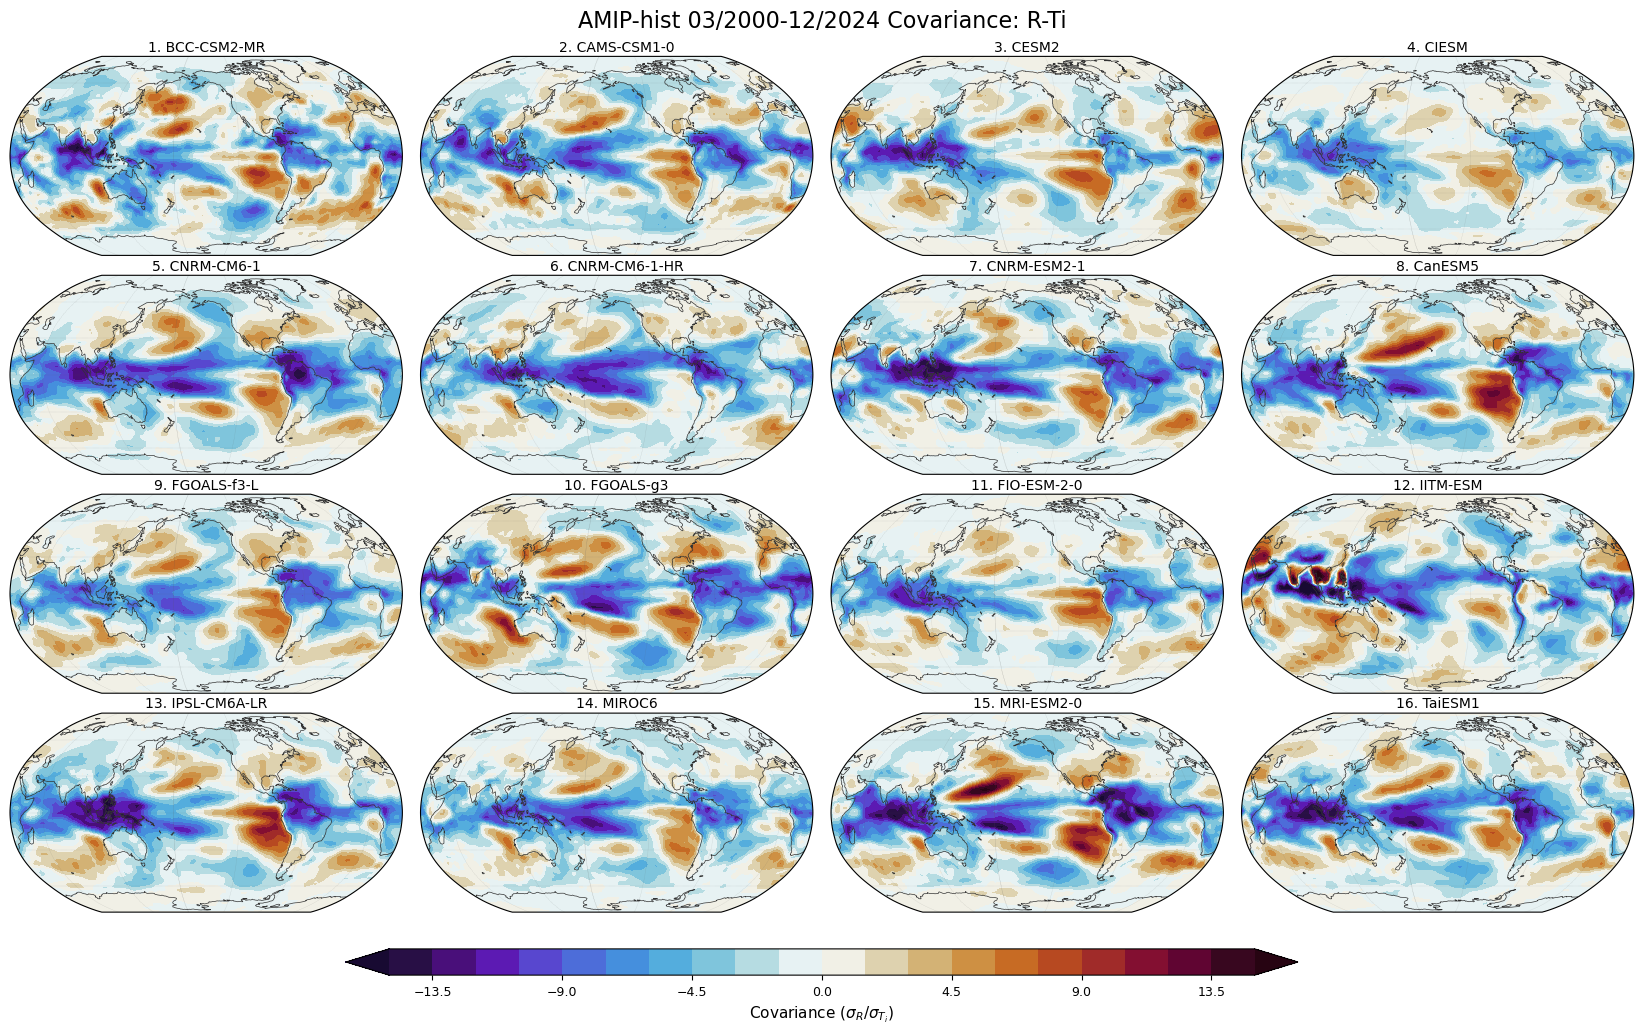

In [12]:
fig, axes = plot_16_model_maps(
    covRTi_amip_hist_ensmeans,
    amip_hist_models,
    lat,
    lon,
    # robust_masks=covRTi_amip_hist_ens_fdr_sig,
    # overlay_style="stipple",
    # overlay_for="significant",
    # stipple_stride=1,
    cmap = cmr.fusion_r,
    vlim = 15,
    title="AMIP-hist 03/2000-12/2024 Covariance: R-Ti",
    colorbar_label = r"Covariance ($\sigma_{R}/\sigma_{T_i}$)",
    # savepath = "./data/maps_2000_2014/amip_hist/covRTi_ensmeans_amip_hist",  
)

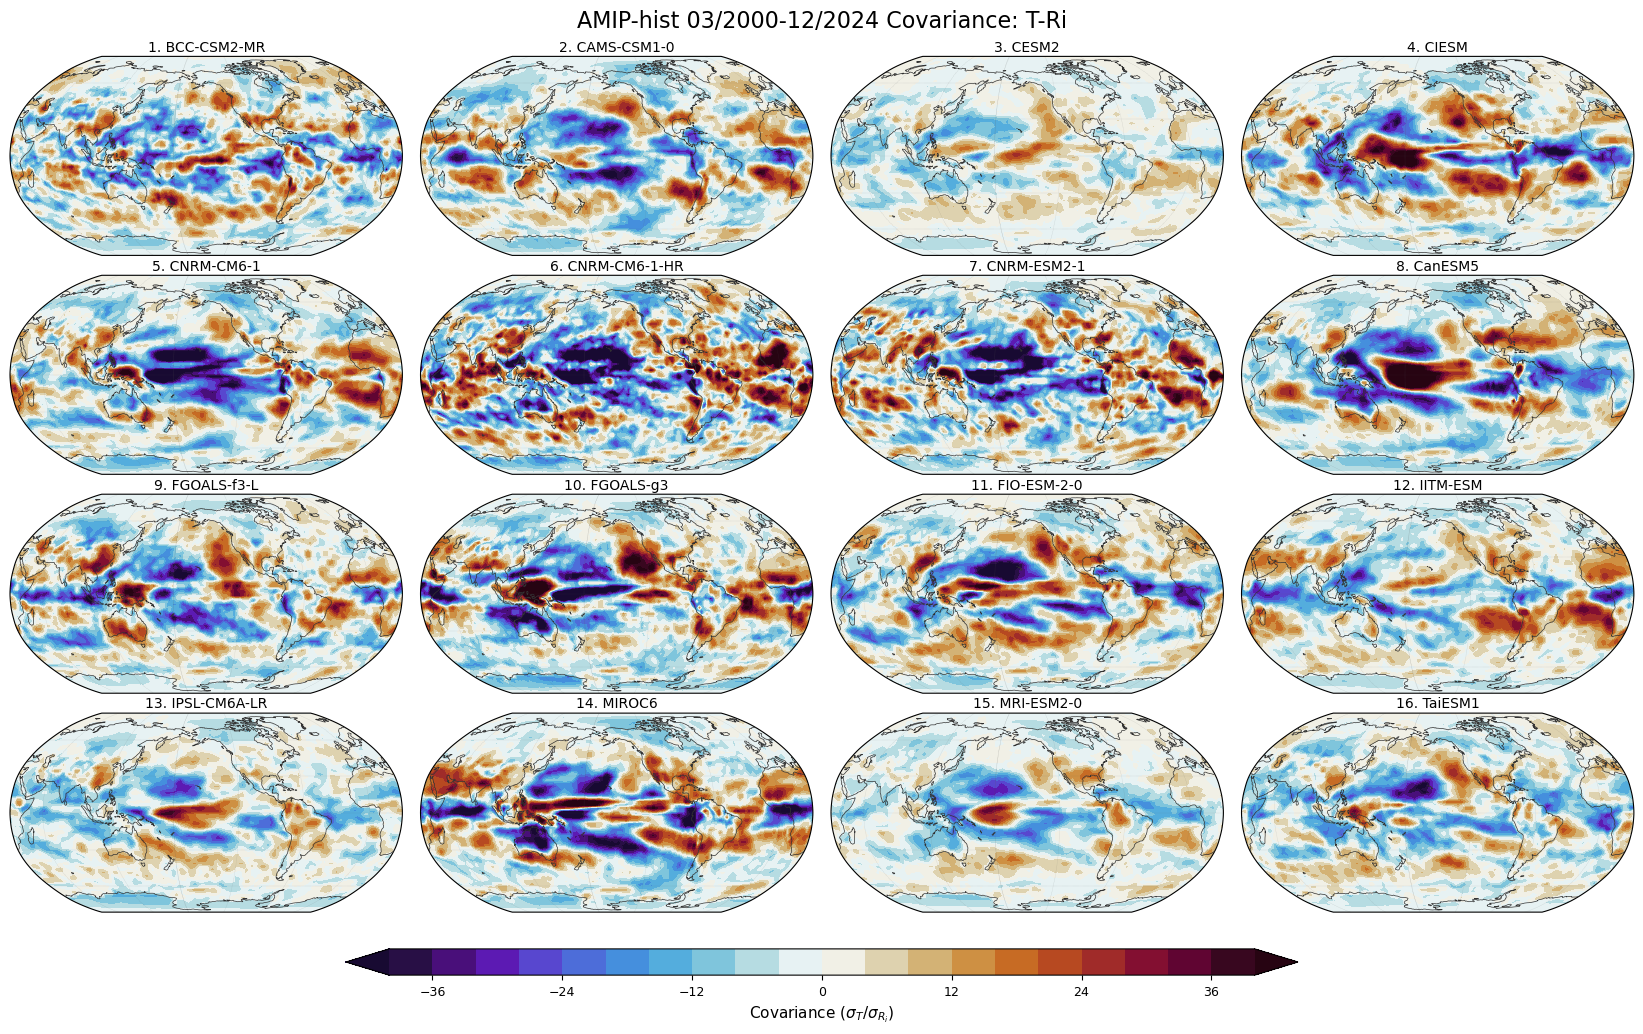

In [13]:
fig, axes = plot_16_model_maps(
    covTRi_amip_hist_ensmeans,
    amip_hist_models,
    lat,
    lon,
    # robust_masks=covRTi_amip_hist_ens_fdr_sig,
    # overlay_style="stipple",
    # overlay_for="significant",
    # stipple_stride=1,
    cmap = cmr.fusion_r,
    vlim = 40,
    title="AMIP-hist 03/2000-12/2024 Covariance: T-Ri",
    colorbar_label = r"Covariance ($\sigma_{T}/\sigma_{R_i}$)",
    # savepath = "./data/maps_2000_2014/amip_hist/covTRi_ensmeans_amip_hist",  
)

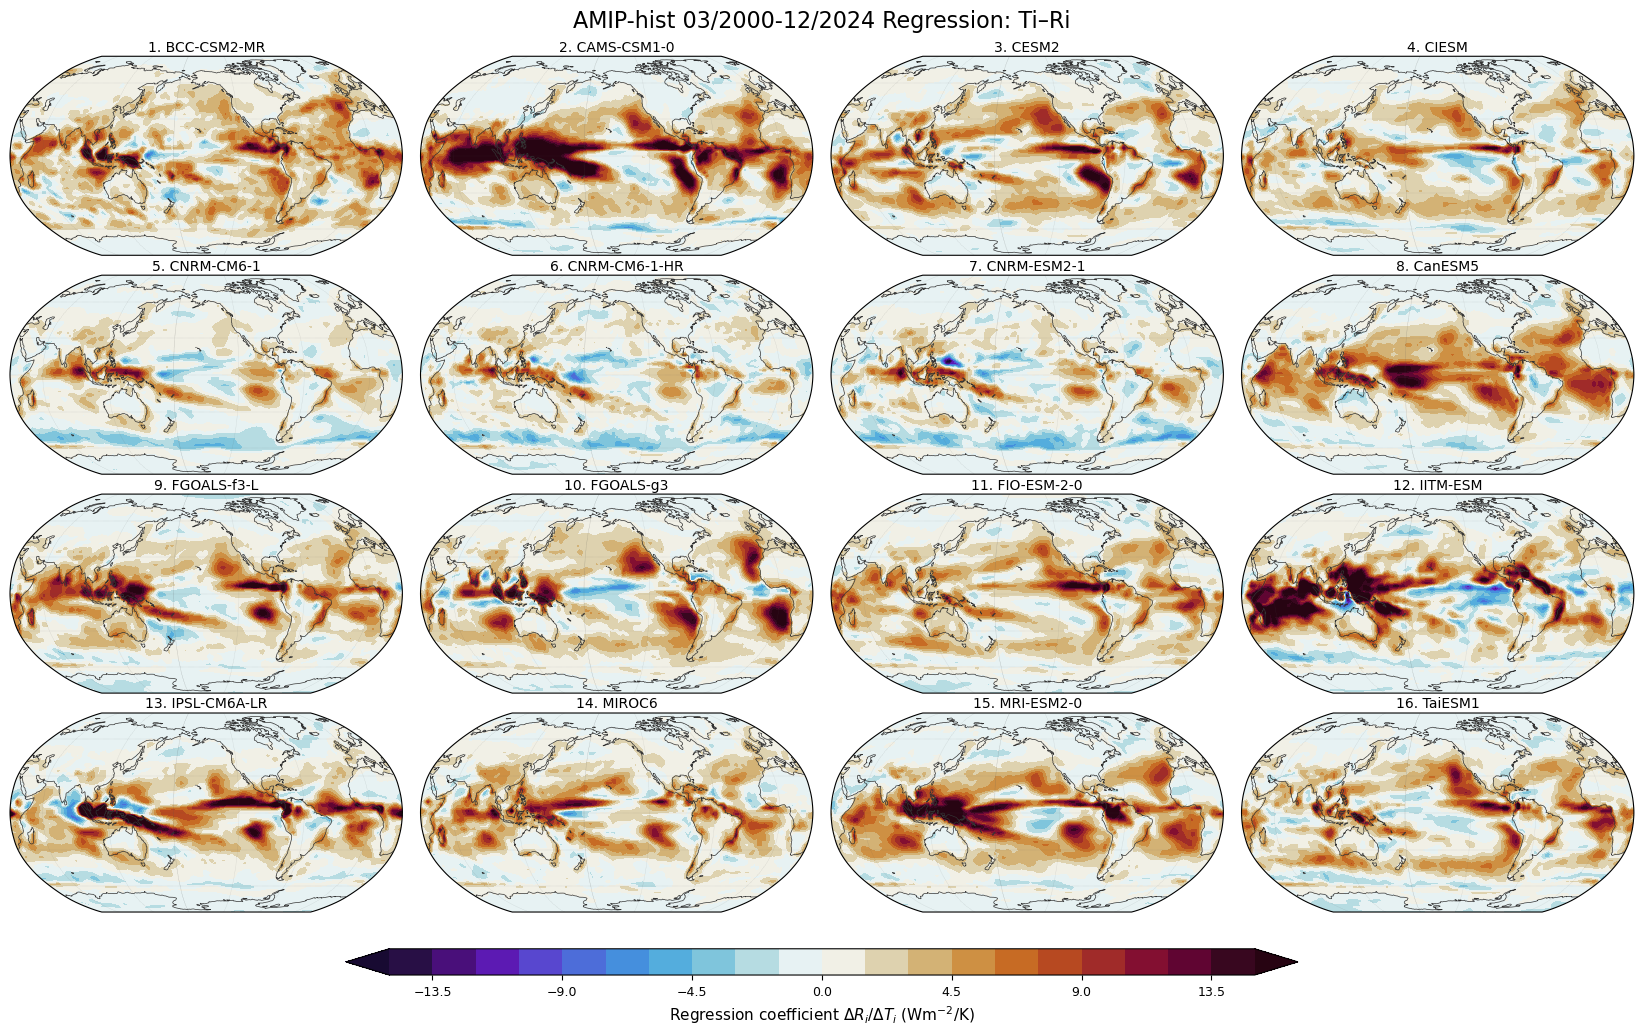

In [14]:
fig, axes = plot_16_model_maps(
    regTiRi_amip_hist_ensmeans,
    amip_hist_models,
    lat,
    lon,
    cmap = cmr.fusion_r,
    vlim = 15,
    title="AMIP-hist 03/2000-12/2024 Regression: Ti–Ri",
    colorbar_label = r"Regression coefficient $\Delta R_i / \Delta T_i$ (Wm$^{-2}$/K)",
    # savepath = "./data/maps_2000_2014/amip_hist/regTiRi_ensmeans_amip_hist",  
)

In [15]:
# plot_3_observation_maps with optional stippling or hatching

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path


def plot_3_observation_maps(
    maps,
    lat,
    lon,
    panel_titles,
    *,
    figure_title="Observations",
    colorbar_labels=None,
    cmaps="RdBu_r",
    vlims=None,
    robust_percentile=98,
    number_of_levels=21,
    central_longitude=0,

    # Optional significance/robustness overlay
    robust_masks=None,
    overlay_style="stipple",          # "stipple" or "hatch"
    overlay_for="significant",        # "significant" or "not_significant"

    # Custom scatter stippling
    stipple_stride=3,
    stipple_size=2.0,
    stipple_color="black",
    stipple_alpha=0.65,
    stipple_marker=".",

    # Hatching
    hatch_pattern="....",
    hatch_color="black",
    hatch_linewidth=0.5,

    savepath=None,
    dpi=200,
):
    """
    Plot three observational maps vertically.

    Parameters
    ----------
    maps
        List or array containing three maps. Each map must have shape
        (lat, lon).

    lat, lon
        One-dimensional spatial coordinates.

    panel_titles
        Three panel titles in top-to-bottom order.

    colorbar_labels
        Three colorbar labels. Defaults to blank labels.

    cmaps
        One colormap name or a list of three colormap names.

    vlims
        Three symmetric absolute color limits. Use None for automatic
        robust limits. A single number applies to all three panels.

    robust_masks
        Optional Boolean or 0/1 significance/robustness mask.

        Accepted shapes are:

            (lat, lon)
                One common mask applied to all three panels.

            (3, lat, lon)
                A separate mask for each panel.

        True or 1 means significant/robust. NaNs are not overlaid.

    overlay_style
        "stipple" uses a custom scatter overlay.
        "hatch" uses contour hatching.

    overlay_for
        "significant" overlays True portions of robust_masks.
        "not_significant" overlays False portions of robust_masks.

    stipple_stride
        Plot one stipple point every N grid cells in both directions.
        Use 1 to consider every grid cell.

    savepath
        Optional output filename.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes.
    """

    # ---------------------------------------------------------
    # Prepare and validate maps
    # ---------------------------------------------------------

    if len(maps) != 3:
        raise ValueError(
            f"Expected three maps, received {len(maps)}"
        )

    if len(panel_titles) != 3:
        raise ValueError(
            "panel_titles must contain exactly three titles"
        )

    maps = np.stack(
        [np.asarray(panel_map) for panel_map in maps],
        axis=0,
    )

    lat = np.asarray(lat)
    lon = np.asarray(lon)

    if lat.ndim != 1 or lon.ndim != 1:
        raise ValueError(
            "lat and lon must be one-dimensional"
        )

    if maps.shape[1:] != (len(lat), len(lon)):
        raise ValueError(
            f"Map shape {maps.shape[1:]} does not match "
            f"lat/lon lengths {(len(lat), len(lon))}"
        )

    # ---------------------------------------------------------
    # Prepare panel-specific plotting options
    # ---------------------------------------------------------

    if colorbar_labels is None:
        colorbar_labels = ["", "", ""]

    if len(colorbar_labels) != 3:
        raise ValueError(
            "colorbar_labels must contain exactly three labels"
        )

    if isinstance(cmaps, str):
        cmaps = [cmaps] * 3
    else:
        cmaps = list(cmaps)

    if len(cmaps) != 3:
        raise ValueError(
            "cmaps must be one name or a list of three names"
        )

    if vlims is None:
        vlims = [None, None, None]

    elif np.isscalar(vlims):
        vlims = [float(vlims)] * 3

    else:
        vlims = list(vlims)

    if len(vlims) != 3:
        raise ValueError(
            "vlims must be one number or a list of three values"
        )

    # ---------------------------------------------------------
    # Validate robustness overlay options
    # ---------------------------------------------------------

    if overlay_style not in {"stipple", "hatch"}:
        raise ValueError(
            "overlay_style must be 'stipple' or 'hatch'"
        )

    if overlay_for not in {
        "significant",
        "not_significant",
    }:
        raise ValueError(
            "overlay_for must be 'significant' "
            "or 'not_significant'"
        )

    if not isinstance(stipple_stride, (int, np.integer)):
        raise TypeError(
            "stipple_stride must be an integer"
        )

    if stipple_stride < 1:
        raise ValueError(
            "stipple_stride must be at least 1"
        )

    common_robust_mask = False

    if robust_masks is not None:
        robust_masks = np.asarray(robust_masks)

        if robust_masks.ndim == 2:

            if robust_masks.shape != (len(lat), len(lon)):
                raise ValueError(
                    f"2-D robust_masks has shape "
                    f"{robust_masks.shape}; expected "
                    f"{(len(lat), len(lon))}"
                )

            common_robust_mask = True

        elif robust_masks.ndim == 3:

            expected_shape = (
                3,
                len(lat),
                len(lon),
            )

            if robust_masks.shape != expected_shape:
                raise ValueError(
                    f"3-D robust_masks has shape "
                    f"{robust_masks.shape}; expected "
                    f"{expected_shape}"
                )

        else:
            raise ValueError(
                "robust_masks must have shape "
                "(lat, lon) or (3, lat, lon)"
            )

    longitude_is_cyclic = np.isclose(
        abs(lon[-1] - lon[0]),
        360.0,
    )

    # ---------------------------------------------------------
    # Create figure
    # ---------------------------------------------------------

    projection = ccrs.Robinson(
        central_longitude=central_longitude
    )

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12, 11.5),
        subplot_kw={"projection": projection},
        constrained_layout=True,
    )

    axes = np.asarray(axes).ravel()

    # ---------------------------------------------------------
    # Plot panels
    # ---------------------------------------------------------

    for panel_index, ax in enumerate(axes):

        panel_map = maps[panel_index]
        panel_vlim = vlims[panel_index]

        # -----------------------------------------------------
        # Determine the color scale
        # -----------------------------------------------------

        if panel_vlim is None:

            finite_values = np.abs(
                panel_map[np.isfinite(panel_map)]
            )

            if finite_values.size == 0:
                raise ValueError(
                    f"Panel {panel_index + 1} "
                    "has no finite values"
                )

            panel_vlim = np.percentile(
                finite_values,
                robust_percentile,
            )

            if panel_vlim == 0:
                panel_vlim = np.max(finite_values)

            if panel_vlim == 0:
                panel_vlim = 1.0

        levels = np.linspace(
            -panel_vlim,
            panel_vlim,
            number_of_levels,
        )

        # -----------------------------------------------------
        # Add a cyclic longitude point
        # -----------------------------------------------------

        if longitude_is_cyclic:
            plot_map = panel_map
            plot_lon = lon

        else:
            plot_map, plot_lon = add_cyclic_point(
                panel_map,
                coord=lon,
                axis=-1,
            )

        # -----------------------------------------------------
        # Plot the filled field
        # -----------------------------------------------------

        mappable = ax.contourf(
            plot_lon,
            lat,
            plot_map,
            levels=levels,
            cmap=cmaps[panel_index],
            extend="both",
            transform=ccrs.PlateCarree(),
        )

        # -----------------------------------------------------
        # Optional significance/robustness overlay
        # -----------------------------------------------------

        if robust_masks is not None:

            if common_robust_mask:
                panel_mask = robust_masks
            else:
                panel_mask = robust_masks[panel_index]

            # True or nonzero values mean significant/robust.
            # NaNs are always excluded.
            mask_is_valid = np.isfinite(panel_mask)

            mask_is_true = (
                mask_is_valid &
                (panel_mask != 0)
            )

            if overlay_for == "significant":
                display_mask = mask_is_true

            else:
                display_mask = (
                    mask_is_valid &
                    ~mask_is_true
                )

            # Do not overlay locations where the map is missing.
            display_mask &= np.isfinite(panel_map)

            if np.any(display_mask):

                # ---------------------------------------------
                # Custom scatter stippling
                # ---------------------------------------------

                if overlay_style == "stipple":

                    sampled_mask = display_mask[
                        ::stipple_stride,
                        ::stipple_stride,
                    ]

                    sampled_lat = lat[
                        ::stipple_stride
                    ]

                    sampled_lon = lon[
                        ::stipple_stride
                    ]

                    lat_indices, lon_indices = np.where(
                        sampled_mask
                    )

                    ax.scatter(
                        sampled_lon[lon_indices],
                        sampled_lat[lat_indices],
                        s=stipple_size,
                        c=stipple_color,
                        alpha=stipple_alpha,
                        marker=stipple_marker,
                        linewidths=0,
                        transform=ccrs.PlateCarree(),
                        zorder=4,
                    )

                # ---------------------------------------------
                # Contour hatching
                # ---------------------------------------------

                elif overlay_style == "hatch":

                    hatch_map = np.where(
                        display_mask,
                        1.0,
                        np.nan,
                    )

                    if longitude_is_cyclic:
                        plot_hatch_map = hatch_map
                        plot_hatch_lon = lon

                    else:
                        (
                            plot_hatch_map,
                            plot_hatch_lon,
                        ) = add_cyclic_point(
                            hatch_map,
                            coord=lon,
                            axis=-1,
                        )

                    with mpl.rc_context({
                        "hatch.color": hatch_color,
                        "hatch.linewidth": hatch_linewidth,
                    }):

                        hatch_artist = ax.contourf(
                            plot_hatch_lon,
                            lat,
                            plot_hatch_map,
                            levels=[0.5, 1.5],
                            colors="none",
                            hatches=[hatch_pattern],
                            transform=ccrs.PlateCarree(),
                            zorder=4,
                        )

                        # Preserve hatch appearance across
                        # Matplotlib versions.
                        if hasattr(
                            hatch_artist,
                            "collections",
                        ):
                            for collection in (
                                hatch_artist.collections
                            ):
                                collection.set_edgecolor(
                                    hatch_color
                                )
                                collection.set_facecolor(
                                    "none"
                                )

        # -----------------------------------------------------
        # Geographic formatting
        # -----------------------------------------------------

        ax.set_global()

        ax.coastlines(
            resolution="110m",
            linewidth=0.55,
            color="0.2",
            zorder=5,
        )

        ax.gridlines(
            linewidth=0.3,
            color="0.35",
            alpha=0.4,
            linestyle=":",
        )

        panel_letter = chr(
            ord("a") + panel_index
        )

        ax.set_title(
            f"({panel_letter}) "
            f"{panel_titles[panel_index]}",
            fontsize=14,
            pad=5,
        )

        # -----------------------------------------------------
        # Individual panel colorbar
        # -----------------------------------------------------

        colorbar = fig.colorbar(
            mappable,
            ax=ax,
            orientation="horizontal",
            pad=0.035,
            fraction=0.055,
            aspect=35,
            extend="both",
        )

        colorbar.set_label(
            colorbar_labels[panel_index],
            fontsize=12,
        )

        colorbar.ax.tick_params(
            labelsize=9,
        )

    # ---------------------------------------------------------
    # Figure title
    # ---------------------------------------------------------

    fig.suptitle(
        figure_title,
        fontsize=16,
    )

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------

    if savepath is not None:

        savepath = Path(savepath)

        savepath.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            savepath,
            dpi=dpi,
            bbox_inches="tight",
        )

        print(f"Saved: {savepath}")

    return fig, axes

In [16]:
## Test robustness by requiring 14 of 16 agree and are significant using FDR adjustment
covRTi_amip_hist_MMM_robust_14 = (
    (covRTi_amip_hist_MMM_nmodels_agree >= 14) &
    covRTi_amip_hist_MMM_fdr_sig
)

covTRi_amip_hist_MMM_robust_14 = (
    (covTRi_amip_hist_MMM_nmodels_agree >= 14) &
    covTRi_amip_hist_MMM_fdr_sig
)

regTiRi_amip_hist_MMM_robust_14 = (
    (regTiRi_amip_hist_MMM_nmodels_agree >= 14) &
    regTiRi_amip_hist_MMM_fdr_sig
)

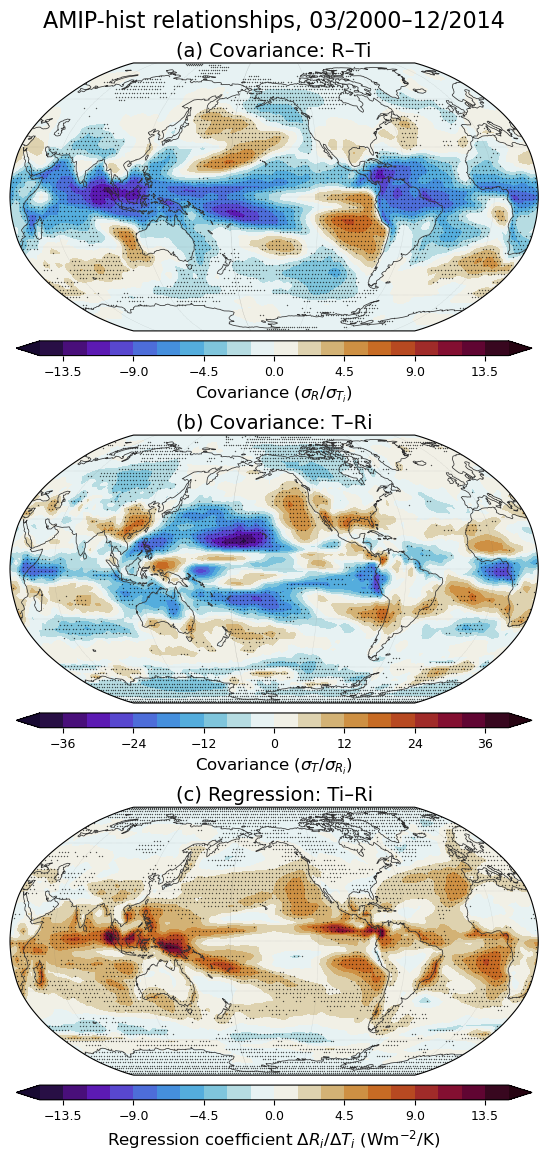

In [17]:
threeMap_robust_masks = np.stack([
    covRTi_amip_hist_MMM_robust_14,
    covTRi_amip_hist_MMM_robust_14,
    regTiRi_amip_hist_MMM_robust_14,
])

fig, axes = plot_3_observation_maps(
    maps=[
        covRTi_amip_hist_MMM,
        covTRi_amip_hist_MMM,
        regTiRi_amip_hist_MMM,
    ],
    lat=lat,
    lon=lon,
    panel_titles=[
        "Covariance: R–Ti",
        "Covariance: T–Ri",
        "Regression: Ti–Ri",
    ],
    colorbar_labels=[
        r"Covariance ($\sigma_{R}/\sigma_{T_i}$)",
        r"Covariance ($\sigma_{T}/\sigma_{R_i}$)",
        r"Regression coefficient $\Delta R_i / \Delta T_i$ (Wm$^{-2}$/K)",
    ],
    figure_title="AMIP-hist relationships, 03/2000–12/2014",
    central_longitude=210,
    cmaps="cmr.fusion_r",
    vlims = [15,40,15],
    # savepath = "./data/maps_2000_2014/amip_hist/threeMaps_amip_hist",
    robust_masks=threeMap_robust_masks,
    overlay_style="stipple",
    overlay_for="significant",
    stipple_stride=1,
    stipple_size=4.0,
)

In [18]:
# fig, axes = plot_3_observation_maps(
#     maps=[
#         covRTi_obs,
#         covTRi_obs,
#         regTiRi_obs,
#     ],
#     lat=ERA5.lat,
#     lon=ERA5.lon,
#     panel_titles=[
#         "Covariance: R–Ti",
#         "Covariance: T–Ri",
#         "Regression: Ti–Ri",
#     ],
#     colorbar_labels=[
#         r"Covariance ($\sigma_{R}/\sigma_{T_i}$)",
#         r"Covariance ($\sigma_{T}/\sigma_{R_i}$)",
#         r"Regression coefficient $\Delta R_i / \Delta T_i$ (Wm$^{-2}$/K)",
#     ],
#     figure_title="AMIP-hist relationships, 03/2000–12/2014",
#     central_longitude=210,
#     cmaps="cmr.fusion_r",
#     vlims = [15,40,15],
#     savepath = "./data/maps_2000_2014/amip_hist/threeMaps_amip_hist"
# )

In [19]:
kill
# np.save("./data/maps_2000_2014/amip_hist/covRTi_amip_hist_ensmeans.npy",covRTi_amip_hist_ensmeans)
# np.save("./data/maps_2000_2014/amip_hist/covTRi_amip_hist_ensmeans.npy",covTRi_amip_hist_ensmeans)
# np.save("./data/maps_2000_2014/amip_hist/regTiRi_amip_hist_ensmeans.npy",regTiRi_amip_hist_ensmeans)


In [21]:
kill
# np.save("./data/maps_2000_2014/amip_hist/covRTi_amip_hist_MMM.npy",covRTi_amip_hist_MMM)
# np.save("./data/maps_2000_2014/amip_hist/covTRi_amip_hist_MMM.npy",covTRi_amip_hist_MMM)
# np.save("./data/maps_2000_2014/amip_hist/regTiRi_amip_hist_MMM.npy",regTiRi_amip_hist_MMM)



In [20]:
covRTi_amip_hist_ensmeans

array([[[-6.32482732e-02, -6.34986393e-02, -6.40830211e-02, ...,
         -6.17255852e-02, -6.23599833e-02, -6.27805523e-02],
        [-1.54996563e-01, -1.61411254e-01, -1.68120723e-01, ...,
         -1.39394548e-01, -1.43320066e-01, -1.48754175e-01],
        [-1.81851453e-01, -1.87108751e-01, -1.90730189e-01, ...,
         -1.76130031e-01, -1.76166110e-01, -1.77656972e-01],
        ...,
        [-3.90822320e-01, -3.76427825e-01, -3.77281789e-01, ...,
         -4.50086420e-01, -4.25418864e-01, -3.98296578e-01],
        [-3.77779552e-01, -3.70786181e-01, -3.63849501e-01, ...,
         -4.04471761e-01, -3.90204527e-01, -3.81297442e-01],
        [-1.50690388e-01, -1.47317425e-01, -1.47115867e-01, ...,
         -1.55003418e-01, -1.54448592e-01, -1.52227606e-01]],

       [[ 1.51864501e-02,  1.30615032e-02,  1.20567476e-02, ...,
          1.79847679e-02,  1.90973752e-02,  1.92610030e-02],
        [ 1.32250827e-01,  1.32994501e-01,  1.31713211e-01, ...,
          1.32900923e-01,  1.34555354e